# Scania APS - Exploratory Data Analysis
**Arkon Manufacturing AI | Module: ML Classification | Department: Truck Fleet**

APS Failure at Scania Trucks dataset - real data donated by Scania CV AB to UCI ML Repository.

**Business context:** The Air Pressure System (APS) generates compressed air for brakes and suspension.
An APS failure can cause a truck to break down on the road - extremely expensive and dangerous.

**Cost structure (from original Scania competition):**
- False Positive (predict failure, no failure): **cost = 10** (unnecessary inspection)
- False Negative (miss a failure): **cost = 500** (breakdown on road)

→ Missing a real failure is **50x more expensive** than a false alarm.

**Goal:** Understand class imbalance, missing values, and feature distributions.

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import (
    get_device, get_mlflow_uri, save_figure,
    Timer, CheckpointManager, recommended_num_workers
)

print('arkon_utils loaded ✓')

arkon_utils loaded ✓


## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
ASSETS = 'ml'

# Data location, in the same relative form the CMAPSS notebooks use
DATA_DIR = Path('../../data/02_scania/raw')

print(f'python  {sys.version.split()[0]}')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
print(f'raw data: {DATA_DIR} (exists: {DATA_DIR.exists()})')


python  3.12.10
pandas  2.3.3
numpy   2.4.4
raw data: ..\..\data\02_scania\raw (exists: True)


## 2. Load Data

In [3]:
# Load training and test sets - note na_values='na' to handle Scania missing value format
df_train = pd.read_csv(
    DATA_DIR / 'aps_failure_training_set.csv',
    na_values='na',
    skiprows=20   # first 20 rows are description text
)

df_test = pd.read_csv(
    DATA_DIR / 'aps_failure_test_set.csv',
    na_values='na',
    skiprows=20
)

print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')

Train shape: (60000, 171)
Test shape:  (16000, 171)


## 3. First Look

In [4]:
# Show first 5 rows - features are anonymised (aa_000, ab_000, etc.)
df_train.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [5]:
# Check data types - all features should be float, target is string (pos/neg)
print(df_train.dtypes.value_counts())
print(f'\nTarget column unique values: {df_train["class"].unique()}')

float64    169
object       1
int64        1
Name: count, dtype: int64

Target column unique values: ['neg' 'pos']


## 4. Class Balance - Key Issue

In [6]:
# Count positive (APS failure) vs negative (no failure) samples - expect severe imbalance
class_counts = df_train['class'].value_counts()
class_pct    = df_train['class'].value_counts(normalize=True) * 100

print('Class distribution (training set):')
for cls in class_counts.index:
    print(f'  {cls}: {class_counts[cls]:,} samples ({class_pct[cls]:.2f}%)')

print(f'\nImbalance ratio: 1:{class_counts["neg"] // class_counts["pos"]} (neg:pos)')

Class distribution (training set):
  neg: 59,000 samples (98.33%)
  pos: 1,000 samples (1.67%)

Imbalance ratio: 1:59 (neg:pos)


  ✓ Saved → assets\ml\scania_eda_class_imbalance.png


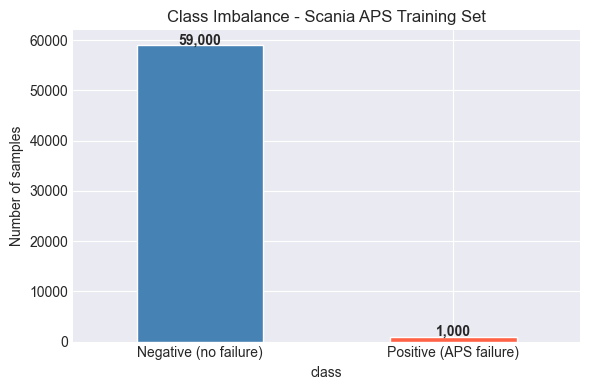

In [7]:
# Visualise class imbalance - shows why accuracy alone is a misleading metric here
fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_xticklabels(['Negative (no failure)', 'Positive (APS failure)'], rotation=0)
ax.set_ylabel('Number of samples')
ax.set_title('Class Imbalance - Scania APS Training Set')

# Add count labels on bars
for i, v in enumerate(class_counts):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
save_figure(fig, 'scania_eda_class_imbalance', subfolder=ASSETS)
plt.show()

## 5. Missing Values Analysis

In [8]:
# Calculate percentage of missing values per feature column
feature_cols = [c for c in df_train.columns if c != 'class']
missing_pct = df_train[feature_cols].isnull().mean() * 100
missing_pct = missing_pct.sort_values(ascending=False)

print(f'Features with >0% missing: {(missing_pct > 0).sum()}')
print(f'Features with >50% missing: {(missing_pct > 50).sum()}')
print(f'Features with >90% missing: {(missing_pct > 90).sum()}')
print(f'\nTop 10 most missing:')
print(missing_pct.head(10).round(1))

Features with >0% missing: 169


Features with >50% missing: 8
Features with >90% missing: 0

Top 10 most missing:
br_000    82.1
bq_000    81.2
bp_000    79.6
bo_000    77.2
ab_000    77.2
cr_000    77.2
bn_000    73.3
bm_000    65.9
bl_000    45.5
bk_000    38.4
dtype: float64


  ✓ Saved → assets\ml\scania_eda_missing_values.png

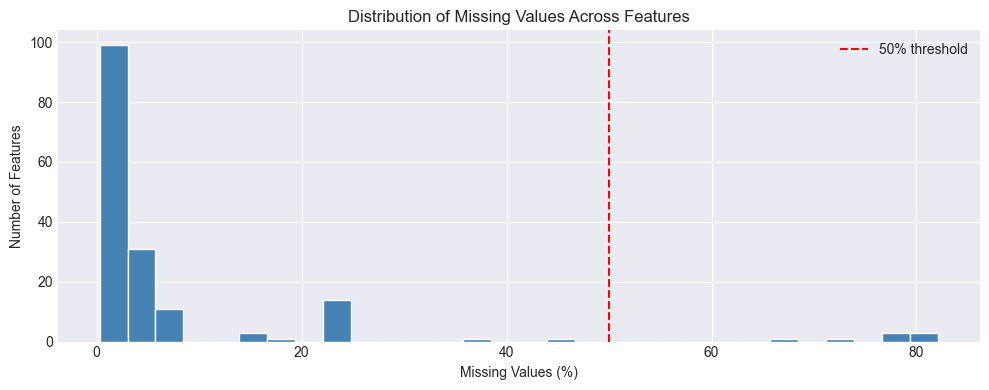

In [9]:
# Plot histogram of missing value percentages across all features
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct[missing_pct > 0].plot(kind='hist', bins=30, ax=ax,
                                   color='steelblue', edgecolor='white')
ax.axvline(50, color='red', linestyle='--', label='50% threshold')
ax.set_xlabel('Missing Values (%)')
ax.set_ylabel('Number of Features')
ax.set_title('Distribution of Missing Values Across Features')
ax.legend()
plt.tight_layout()
save_figure(fig, 'scania_eda_missing_values', subfolder=ASSETS)
plt.show()

## 6. Feature Statistics

In [10]:
# Show descriptive statistics for first 10 features - understand value ranges
df_train[feature_cols[:10]].describe().round(2)

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003
count,60000.00,13671.00,5.666500e+04,4.513900e+04,57500.00,57500.00,59329.00,59329.00,59329.00,59329.00
mean,59336.50,0.71,3.560143e+08,1.906206e+05,6.82,11.01,221.64,975.72,8606.01,88591.28
std,145430.06,3.48,7.948749e+08,4.040441e+07,161.54,209.79,20478.46,34200.53,150322.03,761731.19
min,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00
25%,834.00,0.00,1.600000e+01,2.400000e+01,0.00,0.00,0.00,0.00,0.00,0.00
50%,30776.00,0.00,1.520000e+02,1.260000e+02,0.00,0.00,0.00,0.00,0.00,0.00
75%,48668.00,0.00,9.640000e+02,4.300000e+02,0.00,0.00,0.00,0.00,0.00,0.00
max,2746564.00,204.00,2.130707e+09,8.584298e+09,21050.00,20070.00,3376892.00,4109372.00,10552856.00,63402074.00


## 7. Feature Distribution by Class

  ✓ Saved → assets\ml\scania_eda_feature_distributions.png


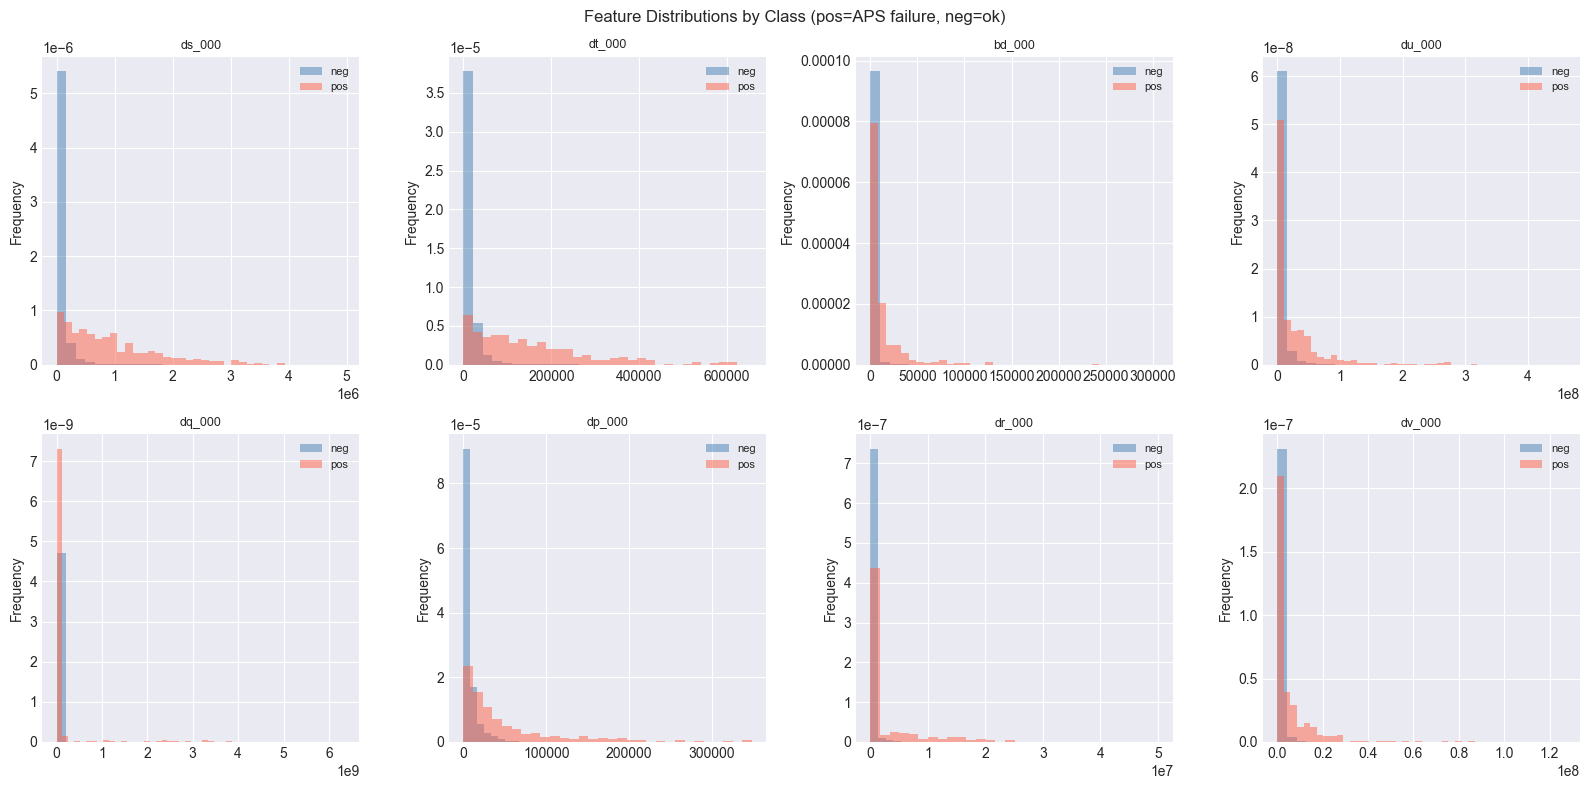

In [11]:
# Compare feature distributions between pos and neg classes for top informative features
# Select features with lowest missing rate for this visualisation
low_missing = missing_pct[missing_pct < 5].index.tolist()[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(low_missing):
    df_train[df_train['class'] == 'neg'][feat].dropna().plot(
        kind='hist', ax=axes[i], alpha=0.5, bins=30,
        color='steelblue', label='neg', density=True
    )
    df_train[df_train['class'] == 'pos'][feat].dropna().plot(
        kind='hist', ax=axes[i], alpha=0.5, bins=30,
        color='tomato', label='pos', density=True
    )
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Class (pos=APS failure, neg=ok)', fontsize=12)
plt.tight_layout()
save_figure(fig, 'scania_eda_feature_distributions', subfolder=ASSETS)
plt.show()

## 8. Cost Analysis

In [12]:
# Calculate what a naive 'always predict negative' model would cost
# This shows why accuracy is misleading and why we need recall-focused evaluation
n_pos = class_counts['pos']  # actual failures
n_neg = class_counts['neg']  # actual non-failures

COST_FP = 10    # false positive: unnecessary inspection
COST_FN = 500   # false negative: breakdown on road

# Naive model: always predict 'no failure'
naive_fn_cost = n_pos * COST_FN  # all real failures missed
naive_fp_cost = 0
naive_accuracy = n_neg / (n_pos + n_neg) * 100

print('Naive model (always predict NEG):')
print(f'  Accuracy:      {naive_accuracy:.1f}%  ← looks good but misleading')
print(f'  False Negatives: {n_pos} missed failures')
print(f'  Total cost:    {naive_fn_cost:,} units')
print(f'\nOur model goal: minimise cost = {COST_FP}×FP + {COST_FN}×FN')

Naive model (always predict NEG):
  Accuracy:      98.3%  ← looks good but misleading
  False Negatives: 1000 missed failures
  Total cost:    500,000 units

Our model goal: minimise cost = 10×FP + 500×FN


## 9. Correlation Among Features (Sample)

  ✓ Saved → assets\ml\scania_eda_correlation.png


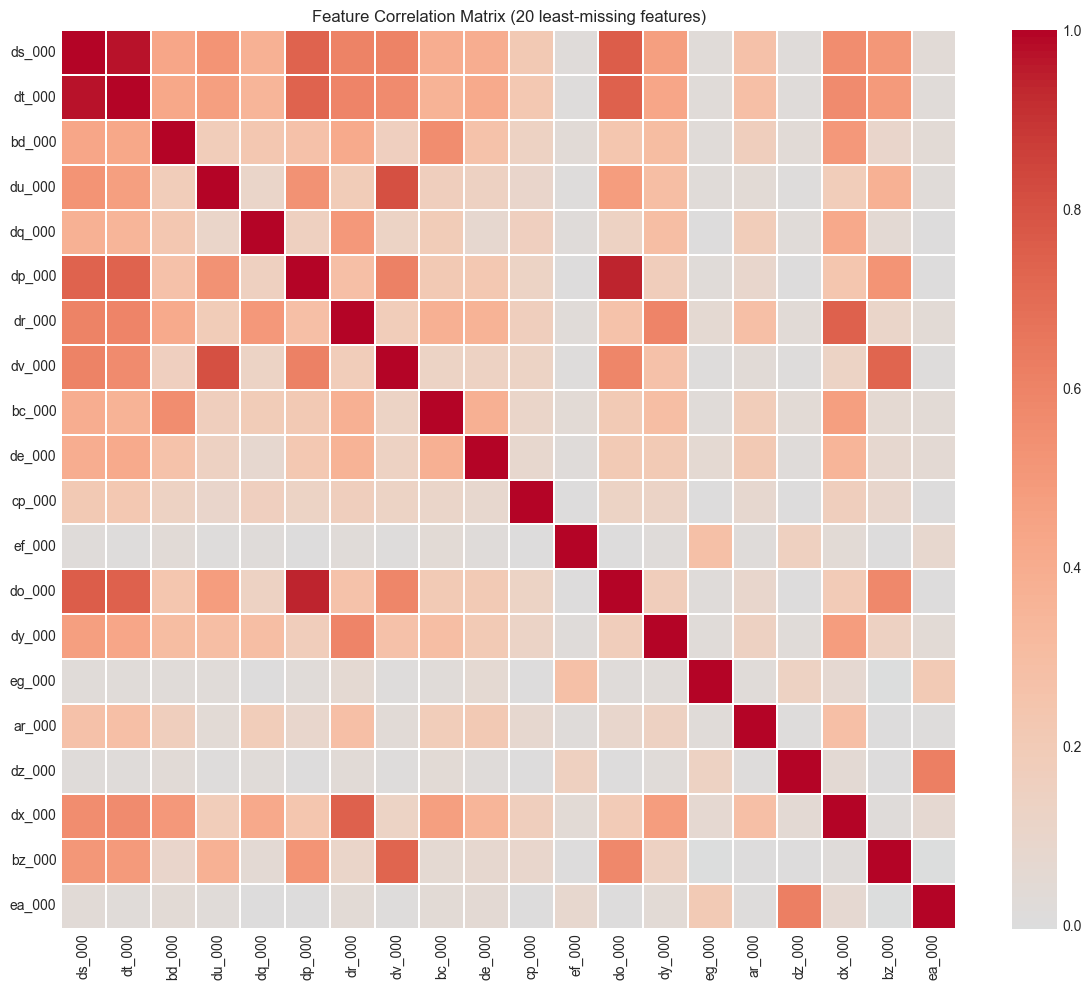

In [13]:
# Plot correlation matrix for 20 features with least missing data
sample_feats = missing_pct[missing_pct < 5].index.tolist()[:20]
corr = df_train[sample_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            linewidths=0.3, annot=False)
ax.set_title('Feature Correlation Matrix (20 least-missing features)')
plt.tight_layout()
save_figure(fig, 'scania_eda_correlation', subfolder=ASSETS)
plt.show()

## 10. Key EDA Findings

| Finding | Detail | Where it is settled |
|---------|--------|---------------------|
| Severe class imbalance | 1,000 failures in 60,000 records, 1 in 59 | Not by resampling. The cost metric carries it, and notebook 03 tunes the decision threshold |
| Missing values everywhere | 169 of 170 counters, 8 of them above half the rows, worst 82.1% | Kept as missing. Notebook 02 section 6 measures how differently they go missing in the two classes |
| 170 anonymised counters | no domain names, nothing a mechanic can act on | No feature selection. The model card records it as limitation 2 |
| Cost-sensitive problem | a missed failure costs as much as 50 needless checks | The decision threshold is this module's main lever, and notebook 03 measures what it is worth |
| Target is a string | 'pos' / 'neg' | Encoded to 1 / 0 where the data is loaded |

**Next step:** `02_scania_preprocessing.ipynb` - every preprocessing decision
measured against this data rather than applied to it.
